# Datasets, splits, and poison-rate mechanics

3 things decide what a PSBD number means before any model is loaded: which images
the dataset gives, how they are cut into a threshold set and an analysis pool, and
how many of the training images the requested poison rate actually reaches.

This notebook reads all 3 out of the library rather than out of a config file, and
checks the properties the rest of the pipeline assumes: the split is a pure
function of (test set size, seed), the clean and backdoor analysis sets are the
same images, and the requested poison rate is not always the realized one.

CPU only. Nothing here loads a checkpoint's weights, only its `args.json`.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import collections
import glob
import json

import matplotlib.pyplot as plt
import pandas as pd
import torch

from psbd.attacks import build_attack, default_config
from psbd.config import DATASET_REGISTRY
from psbd.data import (
    base_image_transform,
    denormalize,
    extract_labels,
    load_clean_datasets,
)
from psbd.eval_loaders import load_test_base
from psbd.poisoning import (
    choose_indices_with_cover,
    choose_poison_indices,
    is_poisonable,
)
from psbd.splits import (
    PSBD_HELDOUT_SIZE,
    PSBD_SPLIT_SEED,
    build_psbd_loaders_from_checkpoint,
    load_clean_test_base,
    psbd_split_permutation,
)

RAW_DATA = "raw_data"
TARGET_LABEL = 0
DATASETS = tuple(DATASET_REGISTRY)
print("datasets:", DATASETS)

datasets: ('cifar10', 'cifar100', 'gtsrb', 'tiny')


## The 4 datasets

`DATASET_REGISTRY` is the only place a dataset's class count, normalization
statistics, loader routing and native resolution are written down, so nothing
below is a number typed into a notebook. `image_size` is the resolution the
pixel-space triggers are defined at, not the 224 the model consumes: the model
wrapper upscales on its own, so resizing earlier would put the trigger on the
wrong pixels.

In [2]:
TRAIN_LABELS = {}
TEST_LABELS = {}
facts = []

for name in DATASETS:
    spec = DATASET_REGISTRY[name]
    train_set, test_set = load_clean_datasets(
        name, base_image_transform(spec.image_size), RAW_DATA
    )
    TRAIN_LABELS[name] = extract_labels(train_set)
    TEST_LABELS[name] = extract_labels(test_set)
    facts.append(
        {
            "dataset": name,
            "classes": spec.num_classes,
            "image_size": spec.image_size,
            "loader_kind": spec.loader_kind,
            "train": len(train_set),
            "test": len(test_set),
            "mean": tuple(round(value, 4) for value in spec.mean),
            "std": tuple(round(value, 4) for value in spec.std),
        }
    )

pd.DataFrame(facts).set_index("dataset")

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


,classes,image_size,loader_kind,train,test,mean,std
dataset,,,,,,,
cifar10,10,32,cifar10,50000,10000,"(0.4914, 0.4822, 0.4465)","(0.2023, 0.1994, 0.201)"
cifar100,100,32,cifar100,50000,10000,"(0.5071, 0.4867, 0.4408)","(0.2673, 0.2564, 0.2762)"
gtsrb,43,32,gtsrb,26640,12630,"(0.0, 0.0, 0.0)","(1.0, 1.0, 1.0)"
tiny,200,64,image_folder,100000,10000,"(0.4802, 0.4481, 0.3975)","(0.2302, 0.2265, 0.2262)"


GTSRB's mean is 0 and its std is 1, which is an identity normalization rather
than a missing entry. BackdoorBench trains its GTSRB models on unnormalized
inputs, so matching that avoids a train and eval mismatch on the reference
checkpoints. The consequence is visible below: for GTSRB the normalized tensor and
the 0-to-1 tensor are the same tensor.

In [3]:
identity_check = {
    name: DATASET_REGISTRY[name].mean == (0.0, 0.0, 0.0)
    and DATASET_REGISTRY[name].std == (1.0, 1.0, 1.0)
    for name in DATASETS
}
print("identity normalization:", identity_check)

# denormalize is the inverse of the Normalize the poisoning wrappers apply last,
# so it is what a visualization has to call before looking at a served tensor.
probe = torch.rand(3, 8, 8)
for name in DATASETS:
    spec = DATASET_REGISTRY[name]
    normalized = (probe - torch.tensor(spec.mean).view(-1, 1, 1)) / torch.tensor(
        spec.std
    ).view(-1, 1, 1)
    assert torch.allclose(denormalize(normalized, name), probe, atol=1e-5)
print("denormalize inverts every registry entry")

identity normalization: {'cifar10': False, 'cifar100': False, 'gtsrb': True, 'tiny': False}
denormalize inverts every registry entry


/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


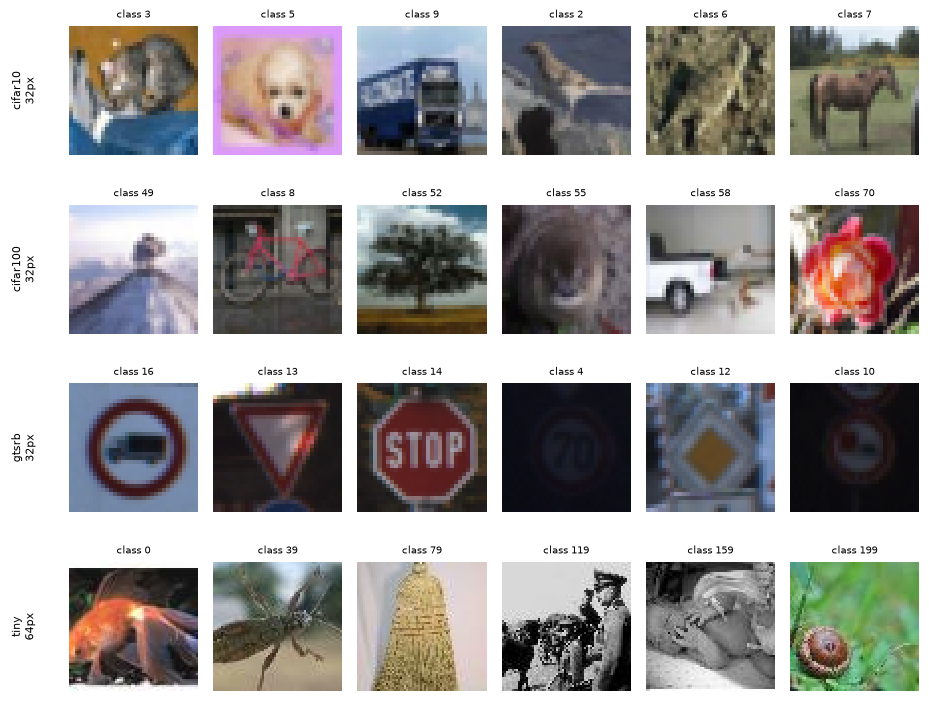

In [4]:
SAMPLES_PER_DATASET = 6


def plot_dataset_samples(dataset_names, samples_per_dataset):
    """One row per dataset, evenly spaced test images at their native resolution."""
    figure, axes = plt.subplots(
        len(dataset_names),
        samples_per_dataset,
        figsize=(1.55 * samples_per_dataset, 1.85 * len(dataset_names)),
    )
    for axis_row, name in zip(axes, dataset_names):
        base, spec = load_test_base(name, RAW_DATA)
        positions = torch.linspace(0, len(base) - 1, samples_per_dataset).long()
        for axis, position in zip(axis_row, positions):
            image, label = base[int(position)]
            axis.imshow(image.permute(1, 2, 0).numpy(), interpolation="nearest")
            axis.set_title(f"class {int(label)}", fontsize=7)
            axis.axis("off")
        axis_row[0].set_ylabel(name)
        axis_row[0].text(
            -0.35,
            0.5,
            f"{name}\n{spec.image_size}px",
            transform=axis_row[0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=8,
        )
    figure.tight_layout()
    return figure


plot_dataset_samples(DATASETS, SAMPLES_PER_DATASET)
plt.show()

## Class balance, which is what the poison rate is capped by

3 of the 4 datasets are perfectly balanced. GTSRB is not, and its smallest class
is 10 times smaller than its largest. That matters here for 1 reason: a
clean-label attack may only poison images of the target class, so the size of
class `TARGET_LABEL` is a hard ceiling on how many images the attack can ever
touch.

In [5]:
balance = []
for name in DATASETS:
    counts = collections.Counter(TRAIN_LABELS[name])
    balance.append(
        {
            "dataset": name,
            "train": len(TRAIN_LABELS[name]),
            "classes": len(counts),
            "min_class": min(counts.values()),
            "max_class": max(counts.values()),
            "target_class_0": counts[TARGET_LABEL],
            "target_share": counts[TARGET_LABEL] / len(TRAIN_LABELS[name]),
        }
    )

pd.DataFrame(balance).set_index("dataset").round(5)

,train,classes,min_class,max_class,target_class_0,target_share
dataset,,,,,,
cifar10,50000,10,5000,5000,5000,0.10000
cifar100,50000,100,500,500,500,0.01000
gtsrb,26640,43,150,1500,150,0.00563
tiny,100000,200,500,500,500,0.00500


`target_share` is the answer to the whole poison-rate question below. It is the
largest poison rate a clean-label attack can reach on that dataset, whatever the
config asks for: 0.1 on CIFAR-10, 0.01 on CIFAR-100, 0.00563 on GTSRB, 0.005 on
Tiny ImageNet.

## The PSBD split

The recipe is 2 lines, and `psbd.splits.psbd_split_permutation` is the single place
they are written:

```python
seed_everything(seed)
permutation = torch.randperm(n_total)
```

`seed_everything` then `randperm` as the very first RNG consumption, so the
permutation is a pure function of (test set size, seed) and of nothing else. Not
of the attack, not of the checkpoint, not of the architecture. Every checkpoint on
a dataset therefore sees the identical split, and hundreds of thousands of cached
per-sample tensors are ordered by that one permutation, which is why those 2 lines
are treated as frozen.

The first 2000 entries are the heldout clean validation set the detection
threshold is read off, matching the 5 percent of the training set the PSBD paper
uses (2000 of CIFAR-10's 50000). Everything after them is the analysis pool.

In [6]:
N_TOTAL = len(TEST_LABELS["cifar100"])

first = psbd_split_permutation(N_TOTAL, PSBD_SPLIT_SEED)
second = psbd_split_permutation(N_TOTAL, PSBD_SPLIT_SEED)
assert torch.equal(first, second), "the split must be reproducible from the seed alone"

heldout = first[:PSBD_HELDOUT_SIZE]
analysis = first[PSBD_HELDOUT_SIZE:]
assert set(heldout.tolist()).isdisjoint(analysis.tolist())
assert len(set(first.tolist())) == N_TOTAL, "a permutation covers every index once"

print(f"split seed            {PSBD_SPLIT_SEED}")
print(f"test set             {N_TOTAL}")
print(f"heldout threshold set {len(heldout)}   first 5 {heldout[:5].tolist()}")
print(f"analysis pool         {len(analysis)}   first 5 {analysis[:5].tolist()}")
print(f"disjoint              {set(heldout.tolist()).isdisjoint(analysis.tolist())}")

Seed set to 0


Seed set to 0


split seed            0
test set             10000
heldout threshold set 2000   first 5 [6044, 2890, 9399, 1917, 4919]
analysis pool         8000   first 5 [768, 9246, 4048, 7488, 2274]
disjoint              True


In [7]:
# The permutation depends on the test set size, so datasets with different test
# sets get different splits, and 2 datasets of the same size get the same one.
sizes = {name: len(TEST_LABELS[name]) for name in DATASETS}
permutations = {name: psbd_split_permutation(size) for name, size in sizes.items()}

print(sizes)
print(
    "cifar10 and cifar100 share a permutation:",
    torch.equal(permutations["cifar10"], permutations["cifar100"]),
)
print(
    "gtsrb differs from cifar100 in length:",
    len(permutations["gtsrb"]) != len(permutations["cifar100"]),
)

Seed set to 0


Seed set to 0


Seed set to 0


Seed set to 0


{'cifar10': 10000, 'cifar100': 10000, 'gtsrb': 12630, 'tiny': 10000}
cifar10 and cifar100 share a permutation: True
gtsrb differs from cifar100 in length: True


## The clean and backdoor sets are the same images

`build_psbd_loaders_from_checkpoint` returns 3 loaders and a manifest. The
manifest is the ground truth row order for every tensor cached under that
checkpoint, so a later analysis can map row `i` of a saved tensor back to an
original test index without rerunning anything.

The pairing claim is specific. The backdoor split is not an independent sample of
poisoned images. It is the analysis pool with the trigger applied, minus the
images the label mode makes ineligible, in the same order. That is what lets a
paired statistic compare row against row.

In [8]:
CHECKPOINT = "checkpoints/vit_cifar100_badnet_a2o_0_01/attack_result.pt"

loaders, manifest = build_psbd_loaders_from_checkpoint(CHECKPOINT, num_workers=0)
clean_set = loaders["clean"].dataset
backdoor_set = loaders["backdoor"].dataset

analysis_indices = manifest["analysis_clean_indices"]
backdoor_indices = manifest["analysis_backdoor_indices"]

print({key: value for key, value in manifest.items() if "indices" not in key})
print()
print(f"validation {len(loaders['validation'].dataset):5d}")
print(f"clean      {len(clean_set):5d}")
print(f"backdoor   {len(backdoor_set):5d}")

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Seed set to 0


{'seed': 0, 'dataset': 'cifar100', 'probe_attack': 'badnet_a2o', 'probe_target_label': 0, 'label_mode': 'all_to_one', 'n_total': 10000, 'n_heldout': 2000, 'recipe_note': 'seed_everything(seed); perm = torch.randperm(n_total); heldout = perm[:n_heldout]; analysis = perm[n_heldout:]'}

validation  2000
clean       8000
backdoor    7915


In [9]:
base_test = load_clean_test_base("cifar100", RAW_DATA)
base_labels = extract_labels(base_test)

assert set(manifest["heldout_indices"]).isdisjoint(analysis_indices)
assert set(backdoor_indices) <= set(analysis_indices)

dropped = set(analysis_indices) - set(backdoor_indices)
dropped_classes = {base_labels[index] for index in dropped}

is_subset = set(backdoor_indices) <= set(analysis_indices)
print(f"heldout and analysis disjoint      {True}")
print(f"backdoor is a subset of analysis   {is_subset}")
print(f"images dropped from the backdoor split {len(dropped)}")
print(f"classes of the dropped images      {sorted(dropped_classes)}")
print(f"target label                       {manifest['probe_target_label']}")

heldout and analysis disjoint      True
backdoor is a subset of analysis   True
images dropped from the backdoor split 85
classes of the dropped images      [0]
target label                       0


In [10]:
# Row-level proof of the pairing: take a row of the backdoor loader, follow the
# manifest back to the original test index, and rebuild both served tensors from
# the raw image.
ROW = 5
position_in_analysis = backdoor_set.indices[ROW]
original_index = analysis_indices[position_in_analysis]
raw_image, raw_label = base_test[original_index]

served_clean = denormalize(clean_set[position_in_analysis][0], "cifar100")
served_backdoor = denormalize(backdoor_set[ROW][0], "cifar100")
expected_backdoor = backdoor_set.attack.apply_trigger(raw_image, original_index)

assert manifest["analysis_backdoor_indices"][ROW] == original_index
assert torch.allclose(served_clean, raw_image, atol=1e-5)
assert torch.allclose(served_backdoor, expected_backdoor, atol=1e-5)

difference = (served_backdoor - served_clean).abs()
print(f"backdoor row {ROW} is test index {original_index}, class {raw_label}")
print(f"its clean twin is analysis position {position_in_analysis}")
print(
    f"the 2 served images differ on {int((difference > 1e-6).sum())} of "
    f"{difference.numel()} values, max {float(difference.max()):.3f}"
)
print("the pair is 1 image, stamped and unstamped")

backdoor row 5 is test index 3267, class 49
its clean twin is analysis position 5
the 2 served images differ on 27 of 3072 values, max 0.847
the pair is 1 image, stamped and unstamped


### The split does not depend on the attack

The same 2 lines run for every checkpoint of a dataset, so a clean-label
checkpoint and a dirty-label one get the identical analysis order. What differs is
which analysis images are eligible for the backdoor split, and for `sig` that
count is the same as for `badnet_a2o`, because `is_eval_poisonable` asks the same
question of both: does the trigger drag a non-target image into the target class.

In [11]:
sig_loaders, sig_manifest = build_psbd_loaders_from_checkpoint(
    "checkpoints/vit_cifar100_sig_0_01/attack_result.pt", num_workers=0
)

assert sig_manifest["analysis_clean_indices"] == analysis_indices
assert sig_manifest["analysis_backdoor_indices"] == backdoor_indices

comparison = pd.DataFrame(
    [
        {
            "checkpoint": "vit_cifar100_badnet_a2o_0_01",
            "label_mode": manifest["label_mode"],
            "n_clean": len(analysis_indices),
            "n_backdoor": len(backdoor_indices),
        },
        {
            "checkpoint": "vit_cifar100_sig_0_01",
            "label_mode": sig_manifest["label_mode"],
            "n_clean": len(sig_manifest["analysis_clean_indices"]),
            "n_backdoor": len(sig_manifest["analysis_backdoor_indices"]),
        },
    ]
).set_index("checkpoint")

print("identical analysis order and identical backdoor eligibility")
comparison

Seed set to 0


identical analysis order and identical backdoor eligibility


,label_mode,n_clean,n_backdoor
checkpoint,,,
vit_cifar100_badnet_a2o_0_01,all_to_one,8000,7915
vit_cifar100_sig_0_01,clean_label,8000,7915


## Poison-rate mechanics

`choose_poison_indices` takes the rate against the whole training set, builds the
eligible pool from `is_poisonable`, and then does this:

```python
requested_count = int(round(poison_rate * len(labels)))
poison_count = min(requested_count, len(eligible))
```

The `min` is the entire subject of the rest of this notebook. For `all_to_one` and
`all_to_all` the eligible pool is the whole dataset or nearly all of it, so the
`min` never binds. For `clean_label` the pool is 1 class.

In [12]:
RATES = (0.01, 0.05, 0.10)
MODE_ATTACKS = {
    "all_to_one": "badnet_a2o",
    "all_to_all": "badnet_a2a",
    "clean_label": "sig",
}

rows = []
for dataset_name in DATASETS:
    spec = DATASET_REGISTRY[dataset_name]
    labels = TRAIN_LABELS[dataset_name]
    for label_mode, attack_name in MODE_ATTACKS.items():
        attack = build_attack(
            attack_name, default_config(attack_name), spec.image_size, TARGET_LABEL
        )
        assert attack.label_mode == label_mode
        for rate in RATES:
            chosen = choose_poison_indices(labels, attack, rate, seed=PSBD_SPLIT_SEED)
            requested_count = int(round(rate * len(labels)))
            rows.append(
                {
                    "dataset": dataset_name,
                    "label_mode": label_mode,
                    "requested_rate": rate,
                    "requested_count": requested_count,
                    "eligible_pool": sum(
                        is_poisonable(attack.label_mode, y, TARGET_LABEL)
                        for y in labels
                    ),
                    "realized_count": len(chosen),
                    "realized_rate": len(chosen) / len(labels),
                    "capped": len(chosen) < requested_count,
                }
            )

poison_frame = pd.DataFrame(rows)
poison_frame.pivot_table(
    index=["dataset", "label_mode"], columns="requested_rate", values="realized_rate"
).round(5)

requested_rate           0.01     0.05     0.10
dataset  label_mode                            
cifar10  all_to_all   0.01000  0.05000  0.10000
         all_to_one   0.01000  0.05000  0.10000
         clean_label  0.01000  0.05000  0.10000
cifar100 all_to_all   0.01000  0.05000  0.10000
         all_to_one   0.01000  0.05000  0.10000
         clean_label  0.01000  0.01000  0.01000
gtsrb    all_to_all   0.00998  0.05000  0.10000
         all_to_one   0.00998  0.05000  0.10000
         clean_label  0.00563  0.00563  0.00563
tiny     all_to_all   0.01000  0.05000  0.10000
         all_to_one   0.01000  0.05000  0.10000
         clean_label  0.00500  0.00500  0.00500

Every `all_to_one` and `all_to_all` cell reads back the rate it was asked for.
GTSRB's 0.00998 at 1 percent is integer rounding on 26640 images, not a cap. Every
`clean_label` row on CIFAR-100, GTSRB and Tiny ImageNet is flat across the 3
requested rates, which is the cap: the same set of images is poisoned whichever
rate was asked for.

In [13]:
capped_rows = poison_frame[poison_frame["capped"]].copy()
capped_rows["overstated_by"] = (
    capped_rows["requested_rate"] / capped_rows["realized_rate"]
)
CAP_COLUMNS = [
    "requested_count",
    "eligible_pool",
    "realized_count",
    "realized_rate",
    "overstated_by",
]
capped_rows.set_index(["dataset", "label_mode", "requested_rate"])[CAP_COLUMNS].round(5)

requested_count  eligible_pool  \
dataset  label_mode  requested_rate                                   
cifar100 clean_label 0.05                       2500            500   
                     0.10                       5000            500   
gtsrb    clean_label 0.01                        266            150   
                     0.05                       1332            150   
                     0.10                       2664            150   
tiny     clean_label 0.01                       1000            500   
                     0.05                       5000            500   
                     0.10                      10000            500   

                                     realized_count  realized_rate  \
dataset  label_mode  requested_rate                                  
cifar100 clean_label 0.05                       500        0.01000   
                     0.10                       500        0.01000   
gtsrb    clean_label 0.01                       150        0.00563   
                     0.05                       150        0.00563   
                     0.10                       150        0.00563   
tiny     clean_label 0.01                       500        0.00500   
                     0.05                       500        0.00500   
                     0.10                       500        0.00500   

                                     overstated_by  
dataset  label_mode  requested_rate                 
cifar100 clean_label 0.05                    5.000  
                     0.10                   10.000  
gtsrb    clean_label 0.01                    1.776  
                     0.05                    8.880  
                     0.10                   17.760  
tiny     clean_label 0.01                    2.000  
                     0.05                   10.000  
                     0.10                   20.000

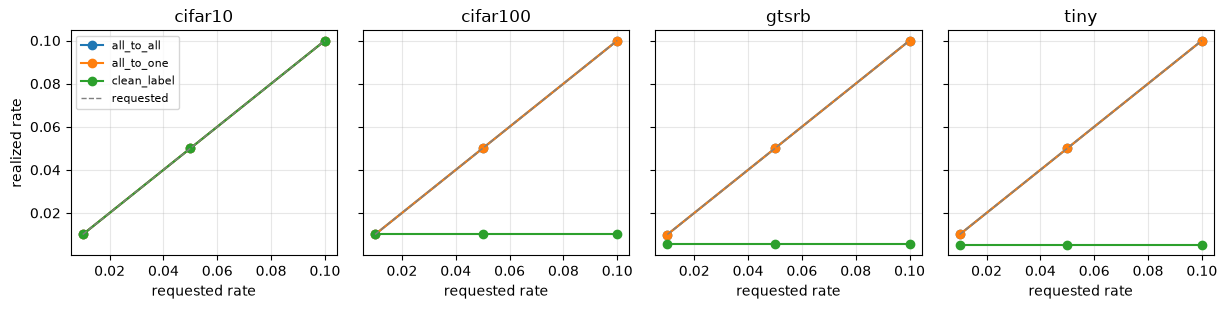

In [14]:
def plot_requested_against_realized(frame):
    """Requested rate against realized rate, 1 panel per dataset."""
    figure, axes = plt.subplots(
        1, len(DATASETS), figsize=(3.1 * len(DATASETS), 3.2), sharey=True
    )
    for axis, dataset_name in zip(axes, DATASETS):
        subset = frame[frame["dataset"] == dataset_name]
        for label_mode, group in subset.groupby("label_mode"):
            axis.plot(
                group["requested_rate"],
                group["realized_rate"],
                marker="o",
                label=label_mode,
            )
        axis.plot(RATES, RATES, ls="--", lw=1, c="grey", label="requested")
        axis.set_title(dataset_name)
        axis.set_xlabel("requested rate")
        axis.grid(alpha=0.3)
    axes[0].set_ylabel("realized rate")
    axes[0].legend(fontsize=8)
    figure.tight_layout()
    return figure


plot_requested_against_realized(poison_frame)
plt.show()

## What the cap means for reading results

This is finding A8 of `docs/audit-2026-09-07.md`, reproduced above from the
library rather than quoted. 180 checkpoints requested a `sig` or `lc` poison rate
they never received, by factors of 5, 10, 17.8 and 20. Every `args.json` now
carries `realized_poison_rate`, `n_poisoned` and `poison_rate_capped`, recovered by
replaying the seeded selection.

The consequence is a rule for reading any table in `docs/`: **a poison-rate trend
involving `sig` or `lc` on CIFAR-100, GTSRB or Tiny ImageNet is not a poison-rate
trend.** Those checkpoints differ in what their folder name says and not in how
many images were poisoned. The Tiny ImageNet `lc` row labelled 10 percent is a 0.5
percent experiment.

In [15]:
RECORDED = [
    "checkpoints/vit_cifar100_sig_0_01/args.json",
    "checkpoints/vit_cifar100_sig_0_05/args.json",
    "checkpoints/vit_cifar100_sig_0_1/args.json",
]

recorded = []
for path in RECORDED:
    with open(path) as handle:
        metadata = json.load(handle)
    recorded.append(
        {
            "checkpoint": Path(path).parent.name,
            "poison_rate": metadata["poison_rate"],
            "realized_poison_rate": metadata["realized_poison_rate"],
            "n_poisoned": metadata["n_poisoned"],
            "poison_rate_capped": metadata["poison_rate_capped"],
        }
    )

pd.DataFrame(recorded).set_index("checkpoint")

,poison_rate,realized_poison_rate,n_poisoned,poison_rate_capped
checkpoint,,,,
vit_cifar100_sig_0_01,0.01,0.01,500,False
vit_cifar100_sig_0_05,0.05,0.01,500,True
vit_cifar100_sig_0_1,0.10,0.01,500,True


## What can be done about the cap

A8 established the cap and stopped there. Splitting it into the part that is
arithmetic and the part that is a choice turns out to matter, because only 1 of
the 4 datasets has any room in it.

The cap is `|target class| / |train set|`, and 3 of the 4 datasets are perfectly
class-balanced. On a balanced dataset every class is the same size, so **no choice
of target label changes anything**: CIFAR-100 tops out at 1 percent and Tiny
ImageNet at 0.5 percent whichever class the attacker picks.

GTSRB is the exception, and it is the one where `target_share` looked worst.
Class 0 holds 150 images. Classes 1 and 2 hold 1500 each, which is a 10 times
larger pool and lifts the cap from 0.56 percent to 5.63 percent. Nothing in the
threat model forces an attacker to pick the rarest class out of 43, so class 0 was
a handicap this project imposed on itself rather than a property of the problem.

The cell below computes, per dataset, which of the requested rates are reachable
at the best available target class.

In [16]:
CANDIDATE_RATES = (0.005, 0.01, 0.05, 0.10)

reach = []
for dataset_name in DATASETS:
    counts = collections.Counter(TRAIN_LABELS[dataset_name])
    total = len(TRAIN_LABELS[dataset_name])
    largest = max(counts.values())
    best_classes = sorted(k for k, v in counts.items() if v == largest)
    reachable = [r for r in CANDIDATE_RATES if round(r * total) <= largest]
    reach.append(
        {
            "dataset": dataset_name,
            "balanced": min(counts.values()) == largest,
            "class_0": counts[TARGET_LABEL],
            "largest_class": largest,
            "cap_at_class_0": counts[TARGET_LABEL] / total,
            "cap_at_best": largest / total,
            "gain": largest / max(counts[TARGET_LABEL], 1),
            "reachable_rates": ", ".join(f"{r:.1%}" for r in reachable) or "none",
            "best_target": best_classes[0],
        }
    )

reach_frame = pd.DataFrame(reach).set_index("dataset")
reach_frame.round(5)

,balanced,class_0,largest_class,cap_at_class_0,cap_at_best,gain,reachable_rates,best_target
dataset,,,,,,,,
cifar10,True,5000,5000,0.10000,0.10000,1.0,"0.5%, 1.0%, 5.0%, 10.0%",0
cifar100,True,500,500,0.01000,0.01000,1.0,"0.5%, 1.0%",0
gtsrb,False,150,1500,0.00563,0.05631,10.0,"0.5%, 1.0%, 5.0%",1
tiny,True,500,500,0.00500,0.00500,1.0,0.5%,0


`gain` is 1.0 on the 3 balanced datasets and 10.0 on GTSRB, which is the whole
result. Switching the clean-label target to class 1 buys GTSRB back its 1 percent
and 5 percent cells. It does not buy 10 percent: 10 percent of 26640 is 2664 and
the largest class holds 1500, so the GTSRB clean-label rows stop at 5 percent and
that is a fact about the dataset rather than a gap in the sweep.

Read `reachable_rates` as the permanent limit, since it is already computed at the
best class available:

- **10 percent clean-label is impossible on 3 of the 4 datasets.**
- **5 percent is impossible on CIFAR-100 and Tiny ImageNet.**
- **1 percent is impossible on Tiny ImageNet**, whose ceiling is 0.5 percent.

That last line has a consequence for the panel. `configs/psbd_basis.json` declares
its poison rates as `[0.01, 0.05, 0.1]`, so **Tiny ImageNet can contribute no
clean-label panel cell at all**, and CIFAR-100 can contribute only its 1 percent
one. Those cells were never missing measurements. They were never possible.

New clean-label runs on GTSRB therefore carry `--target-label 1` and a `_tl1`
folder tag. The dirty-label GTSRB cells keep class 0, since the cap does not bind
for them, and a small set of dirty-label runs at class 1 is trained as a control:
if detection AUROC moves with the target class then the switch is a confound and
not a fix.

### The other half of the clean-label problem

The cap explains why `sig` and `lc` could not be run at the rates their folder
names claim. It does not explain why `lc` underperforms even at the cap, and that
turned out to be a separate defect: Turner's Label-Consistent attack perturbs each
base image adversarially before stamping the patch, so the image stops supporting
its own label and the trigger becomes the only cue left. That step was never
implemented here.

The signature of the missing step is visible in the CIFAR-10 column, where nothing
is capped. Patch-only `lc` reads 0.119, 0.249, 0.408 and 0.979 at 0.5, 1, 5 and 10
percent: it only implants at 10 percent, which is exactly 100 percent of the
target class. An attack that needs the entire target class is an attack that is
not using its trigger. `psbd/adversarial.py` and `cli/lc_bases.py` supply the
missing bases, and `docs/clean-label-rate-caps.md` is the full record.

## Cover-sample attacks take a different route

Adaptive-Blend and TaCT do not go through `choose_poison_indices` at all. They go
through `choose_indices_with_cover`, which draws poison indices and cover indices
from 1 generator, poison first, so the seed reproduces the pair rather than each
set alone. Cover samples carry the trigger and keep their true label.

TaCT adds a second restriction that the clean-label attacks do not have:
`source_classes` limits poisoning to the classes the trigger is meant to flip,
which is 1 class by default. That is the same shape of ceiling `clean_label` has,
and it caps the same way.

In [17]:
cover_rows = []
for dataset_name in DATASETS:
    spec = DATASET_REGISTRY[dataset_name]
    labels = TRAIN_LABELS[dataset_name]
    for attack_name in ("adaptive_blend", "tact"):
        config = default_config(attack_name)
        attack = build_attack(attack_name, config, spec.image_size, TARGET_LABEL)
        source_classes = getattr(config, "source_classes", None)
        for rate in RATES:
            poison_indices, cover_indices = choose_indices_with_cover(
                labels,
                attack,
                rate,
                config.cover_rate,
                source_classes,
                seed=PSBD_SPLIT_SEED,
            )
            requested_count = int(round(rate * len(labels)))
            assert not poison_indices & cover_indices, (
                "an image is poisoned or covered, never both"
            )
            cover_rows.append(
                {
                    "dataset": dataset_name,
                    "attack": attack_name,
                    "source_classes": str(source_classes),
                    "requested_rate": rate,
                    "requested_count": requested_count,
                    "realized_count": len(poison_indices),
                    "realized_rate": len(poison_indices) / len(labels),
                    "cover_count": len(cover_indices),
                    "capped": len(poison_indices) < requested_count,
                }
            )

cover_frame = pd.DataFrame(cover_rows)
cover_frame[cover_frame["capped"]].set_index(
    ["dataset", "attack", "requested_rate"]
).round(5)

source_classes  requested_count  \
dataset  attack requested_rate                                   
cifar100 tact   0.05                     (1,)             2500   
                0.10                     (1,)             5000   
gtsrb    tact   0.10                     (1,)             2664   
tiny     tact   0.01                     (1,)             1000   
                0.05                     (1,)             5000   
                0.10                     (1,)            10000   

                                realized_count  realized_rate  cover_count  \
dataset  attack requested_rate                                               
cifar100 tact   0.05                       500        0.01000          500   
                0.10                       500        0.01000          500   
gtsrb    tact   0.10                      1500        0.05631          266   
tiny     tact   0.01                       500        0.00500         1000   
                0.05                       500        0.00500         1000   
                0.10                       500        0.00500         1000   

                                capped  
dataset  attack requested_rate          
cifar100 tact   0.05              True  
                0.10              True  
gtsrb    tact   0.10              True  
tiny     tact   0.01              True  
                0.05              True  
                0.10              True

TaCT is capped on 3 of the 4 datasets, for the same arithmetic reason `sig` is:
its poison pool is 1 class. On CIFAR-100 the 5 percent and 10 percent requests both
resolve to 500 images, which is 1 percent. On Tiny ImageNet all 3 requested rates
resolve to 500 images, which is 0.5 percent. Adaptive-Blend, which poisons any
non-target class, is never capped.

Unlike the `sig` and `lc` case, this is not recorded in the checkpoints.
`scripts/backfill_metadata.py` deliberately skips cover-sample attacks when
replaying the selection, because they route through a different selector, so every
`tact` and `adaptive_blend` folder carries `realized_poison_rate: None`. The cap is
real, reproducible from the library, and invisible in the metadata.

In [18]:
cover_metadata = []
for path in sorted(glob.glob("checkpoints/*/args.json")):
    with open(path) as handle:
        metadata = json.load(handle)
    if not metadata.get("cover_rate"):
        continue
    cover_metadata.append(
        {
            "attack": metadata["attack"],
            "records_realized_rate": metadata.get("realized_poison_rate") is not None,
        }
    )

cover_metadata_frame = pd.DataFrame(cover_metadata)
print(f"cover-sample checkpoints: {len(cover_metadata_frame)}")
print(
    "with a recorded realized_poison_rate: "
    f"{int(cover_metadata_frame['records_realized_rate'].sum())}"
)
cover_metadata_frame.groupby("attack")["records_realized_rate"].agg(["count", "sum"])

cover-sample checkpoints: 314
with a recorded realized_poison_rate: 314


,count,sum
attack,,
adaptive_blend,150,150
bpp,12,12
tact,140,140
wanet,12,12


## What this notebook establishes

1. Every dataset fact used downstream comes from `DATASET_REGISTRY`, including
   GTSRB's deliberate identity normalization and the native trigger resolutions
   of 32 and 64 pixels.
2. The PSBD split is a pure function of (test set size, seed). It reproduces
   exactly, its 2 parts are disjoint, and the 2000-image heldout set is clean
   only.
3. The clean and backdoor analysis sets are the same images in the same order,
   verified at row level by rebuilding both served tensors from 1 raw image. The
   backdoor split is the analysis pool minus the 85 target-class images that
   cannot demonstrate a flip.
4. The requested poison rate is a request. It is capped at the eligible pool, and
   for `clean_label` that pool is 1 class, so CIFAR-100, GTSRB and Tiny ImageNet
   all collapse their 1, 5 and 10 percent requests onto a single realized rate.
5. The same cap hits TaCT through `source_classes`, on 3 of the 4 datasets, and
   no cover-sample checkpoint records it.
6. Only GTSRB has any room in its cap, because only GTSRB is class-imbalanced.
   Moving the clean-label target from class 0 to class 1 multiplies its pool by
   10 and restores its 1 and 5 percent cells. On the 3 balanced datasets no choice
   of target label helps at all, so **10 percent clean-label is impossible outside
   CIFAR-10, and Tiny ImageNet can contribute no clean-label panel cell at any of
   the panel's declared rates.**